# Implementação visual dos testes do projeto
---

## Importações

In [1]:
import os
import sys
import shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import kagglehub

from PIL import Image
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from typing import List, Tuple

/home/gabriel/miniconda3/envs/rna/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Extração dos dados do dataset

In [3]:
# Descobre o diretório atual onde o notebook está rodando
current_notebook_dir = os.getcwd()

# Se o notebook estiver dentro de uma pasta 'notebooks' ou 'src', subimos um nível
# para achar a raiz. Se já estiver na raiz, mantemos.
if os.path.basename(current_notebook_dir) in ['notebooks', 'src', 'scripts']:
    project_root = os.path.dirname(current_notebook_dir)
else:
    project_root = current_notebook_dir

# Adiciona a raiz ao path do Python para conseguir importar seus módulos (utils, models)
if project_root not in sys.path:
    sys.path.append(project_root)

# Define onde queremos que os dados "pareçam" estar
db_folder = os.path.join(project_root, 'db')
os.makedirs(db_folder, exist_ok=True)

print(f"Raiz do Projeto: {project_root}")
print(f"Pasta de Dados (DB): {db_folder}")

# --- 2. Download via KaggleHub ---
print("\nVerificando dataset...")
dataset_path = db_folder

try:
    if len(os.listdir(db_folder)) == 0:
        # Baixa (ou recupera do cache)
        download_path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia", path=db_folder)
        dataset_path = download_path
    print(f"Dataset disponível em: {dataset_path}")

except Exception as e:
    print(f"Erro ao baixar dataset: {e}")
    dataset_path = os.path.join(db_folder, 'chest_xray')
    if os.path.exists(dataset_path):
        print(f"Usando cópia local encontrada em: {dataset_path}")
    else:
        raise FileNotFoundError("Dataset não encontrado e download falhou.")

# --- 3. Teste Rápido de Acesso ---
train_dir_check = os.path.join(dataset_path, 'chest_xray', 'train') 
# Nota: O dataset do kaggle às vezes duplica a pasta (chest_xray/chest_xray)
if not os.path.exists(train_dir_check):
    train_dir_check = os.path.join(dataset_path, 'train')

if os.path.exists(train_dir_check):
    print(f"\nSucesso! Pasta de treino localizada com {len(os.listdir(os.path.join(train_dir_check, 'PNEUMONIA')))} imagens de Pneumonia.")
else:
    print("\nAviso: Estrutura de pastas interna pode estar diferente do esperado. O data_loader cuidará disso.")

Raiz do Projeto: /media/gabriel/Dados/Unifesp/4° Termo/RNA_2025/Projeto_Final
Pasta de Dados (DB): /media/gabriel/Dados/Unifesp/4° Termo/RNA_2025/Projeto_Final/db

Verificando dataset...
Dataset disponível em: /media/gabriel/Dados/Unifesp/4° Termo/RNA_2025/Projeto_Final/db

Sucesso! Pasta de treino localizada com 3876 imagens de Pneumonia.


## Célula de carregamento dos dados em um DataLoader

In [4]:
class CustomImgDataset(Dataset):
    def __init__(
            self,
            df: pd.DataFrame,
            transform: callable = None
    ):
        """
        Args:
            df: DataFrame contendo nomes e tipos.
            img_dir: Caminho para a pasta das imagens.
            transform: Transformações do PyTorch.
        """
        self.df = df # dataframe parcial, abrange apenas o subconjunto tratado
        self.transform = transform
        self.labels = {"NORMAL": 0, "PNEUMONIA": 1}

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, index):
        row = self.df.iloc[index]
        img_path = row['path']
        label_str = row['label']

        try:
            image = Image.open(img_path).convert("L")
        except Exception as e:
            print(f"Erro ao ler {img_path}: {e}")
            # Retorna uma imagem preta em caso de erro para não quebrar o treino
            image = Image.new('L', (224, 224))

        numerical_label = self.labels[label_str]

        if self.transform:
            image = self.transform(image)

        return image, numerical_label
    
def _find_dir(root_path: str) -> str:
    """
    Este dataset possui uma certa inconsistência na importação pelo kagglehub,
    principalmente quando se trata de diretórios aninhados. Para contornar esse problema,
    usamos essa função para chegar à pasta raiz, que possui as pastas de treino,
    validação e teste.

    Args:
        root_path: Caminho inicial retornado pelo módulo do kagglehub
    """
    possibilities = [
        root_path,
        os.path.join(root_path, "chest_xray"),
        os.path.join(root_path, "chest_xray/chest_xray"),        
    ]

    train_dir = "train/"
    final_dir = None # None garante mais segurança caso algo dê errado

    for p in possibilities:
        if os.path.exists(os.path.join(p, train_dir)):
            final_dir = p
            break # encontramos, entao podemos parar o loop

    if final_dir is None:
        raise FileNotFoundError(f"Não foi possível encontrar a pasta 'train' dentro de {root_path}. Verifique o download.")
    
    print(f"Dataset localizado em: {final_dir}")
    return final_dir

def _createDataFrame(root_dir: str):
    """
    Varre as pastas train/test/val e cria um DataFrame único com caminhos e labels.

    Como a pasta de validação é muito pequena (possui apenas 8 imagens para as duas
    classificações), optamos por reunir todas as imagens do dataset e separá-las por
    conta própria.

    Args:
        root_dir: Diretório raiz que contém as três pastas (train, test e val)
    """
    filepaths = []
    labels = []
    
    # As classes são as subpastas
    classes = ["NORMAL", "PNEUMONIA"]
    
    # Percorre train, test e val para juntar todas em um único DataFrame
    for split in ["train", "test", "val"]:
        split_path = os.path.join(root_dir, split)
        if not os.path.exists(split_path): continue
            
        for label in classes:
            class_path = os.path.join(split_path, label)
            if not os.path.exists(class_path): continue
                
            for img_name in os.listdir(class_path):
                if img_name.lower().endswith(('.jpeg', '.jpg', '.png')):
                    full_path = os.path.join(class_path, img_name)
                    filepaths.append(full_path)
                    labels.append(label)
                    
    df = pd.DataFrame({
        'path': filepaths,
        'label': labels
    })
    return df

def _setTransformations() -> Tuple[callable, callable]:
    """
    Função auxiliar que contém as definições das transformações aplicadas nas
    imagens do dataset.
    
    Vale ressaltar um detalhe importante no RandomAffine, a aplicação de um zoom 
    de 5% a 15% na imagem. Fazemos isso a fim de fugir da possibilidade de problemas 
    com ruídos nas rotações, as quais geram tarjas pretas nas bordas da imagem. Ao 
    aplicar esse zoom, sabendo que todas as imagens de raio-X possuem bordas pretas, 
    garantimos que não hajam inconsistências na análise pela CNN. A escolha dos 
    valores do zoom foi feita de modo empírico.
    """
    train_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=1),
        
        transforms.RandomAffine(
            degrees=10,             # Rotação leve (máx 10 graus)
            translate=(0.05, 0.05), # Move um pouco para os lados (5%)
            scale=(1.05, 1.15),     # Zoom entre 5% e 15%
            fill=0                  # Se sobrar espaço, preenche com preto
        ),

        transforms.ToTensor(),
        # transforms.Normalize([0.5], [0.5])
    ])

    val_test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor(),
    ])

    return train_transforms, val_test_transform

def getDataLoaders(
        root_path: str,
        batch_size: int = 32
):
    """
    Carrega os dados em formato de um DataLoader.

    Args:
        root_path: Diretório raiz das pastas dos subconjuntos.
        batch_size: Tamanho dos lotes de treinamento.

    Output:
        Dados separados conforme a proporção definida internamente em conjuntos de treino,
        validação e teste.
    """
    proportions = (0.8, 0.2) # treino e validação + teste
    # --- 1. Carregamento do DataFrame ---
    # Correção do PATH
    path = _find_dir(root_path)
    full_df = _createDataFrame(path)

    # --- 2. Separação dos subconjuntos ---
    train_df, temp = train_test_split(
        full_df,
        test_size=proportions[1],
        stratify=full_df["label"],
        random_state=42
    )

    val_df, test_df = train_test_split(
        temp,
        test_size=0.5,
        stratify=temp["label"],
        random_state=42
    )

    # --- 3. Definição das transformações ---
    train_transforms, val_test_transforms = _setTransformations()

    # --- 4. Instanciação dos DataSets e DataLoaders ---
    train_ds = CustomImgDataset(train_df, train_transforms)
    val_ds = CustomImgDataset(val_df, val_test_transforms)
    test_ds = CustomImgDataset(test_df, val_test_transforms)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4, # colocar em 2 no Colab, caso identifique algum erro
        pin_memory=True
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4
    )

    return train_loader, val_loader, test_loader

## Função de visualização do lote de DataLoader

In [6]:
def sampleBatch(
    dataloader: DataLoader,
    classes: Tuple[str] = ["NORMAL", "PNEUMONIA"]
) -> None:
    """
    Função de visualização do lote que foi extraído na criação dos DataLoaders

    Args:
        dataloader: DataLoader com imagens dos raios-x
        classes: Labels das imagens (normal e pneumonia)
    """
    # Pega um lote de imagens
    images, labels = next(iter(dataloader))
    
    plt.figure(figsize=(12, 4))
    for idx in range(5):
        _ = plt.subplot(1, 5, idx+1)
        # O PyTorch é (C, H, W), o Matplotlib quer (H, W, C)
        img = images[idx].permute(1, 2, 0).cpu().numpy()
        plt.imshow(img)
        plt.title(classes[labels[idx]])
        plt.axis("off")
    plt.show()

## Funções de plotagem das informações do modelo

In [7]:
def plotLosses(
        title,
        loss1: List[float],
        loss2: List[float],
        loss1_label: str,
        loss2_label: str,
        epochs: int,
        saving: str
    ) -> None:
    plt.close("all")
    plt.figure()
    plt.plot(range(epochs), loss1, label=loss1_label)
    plt.plot(range(epochs), loss2, label=loss2_label)
    plt.title(title)
    plt.xlabel("Épocas")
    plt.ylabel("Erro")
    plt.legend()
    plt.savefig(saving)
    plt.show()

def plotCMatrix(
        labels: np.ndarray,
        predicted: np.ndarray,
        class_names: List[str],
        saving: str
    ) -> None:
    # --- 1. Cálculo da Matriz ---
    cm = confusion_matrix(labels, predicted)
    num_classes = cm.shape[0]

    # --- 2. Plotagem ---
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(f"Matriz de Confusão")
    plt.colorbar()
    
    # Define os labels dos eixos com os nomes reais (ex: Fire, Water)
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right") # Rotação ajuda a ler
    plt.yticks(tick_marks, class_names)
    
    plt.xlabel("Classe Prevista")
    plt.ylabel("Classe Verdadeira")

    # Escrever os valores em cada célula
    thresh = cm.max() / 2.0
    for i in range(num_classes):
        for j in range(num_classes):
            plt.text(
                j, i, format(cm[i, j], "d"),
                horizontalalignment="center",
                verticalalignment="center", # Centraliza verticalmente também
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.tight_layout() 
    plt.savefig(saving)
    plt.show()

## Classe genérica de rede convolucional

In [8]:
class SimpleCNN_Base(nn.Module):
    """
    Modelo flexível de rede convolucional, desenvolvido de forma a suportar
    distintas arquiteturas, em que a função que cria o modelo pode definir
    se terá dropout, batch normalization e Global Average Pooling.
    """
    def __init__(
            self,
            filters_list: List[int],
            num_classes: int = 2,
            dropout: bool = False,
            batch_norm: bool = False,
            GAP: bool = False,
            input_size: int = 224
    ):
        """
        Args:
            filters_list: Lista que contém as dimensões (quantidade total de neurônios)
                          de cada camada de filtro da CNN.
            num_classes: Quantidade de classificações possíveis.
            dropout: Parâmetro que determina se o modelo utilizará dropout.
            batch_norm: Define se o modelo terá batch normalization.
            GAP: Informa se o modelo utilizará Global Average Pooling
            input_size: Tamanho da imagem, utilizado para quando o modelo não conter GAP
        """
        super(SimpleCNN_Base, self).__init__()
        layers = []
        in_channels = 1 # canais de cor (como trabalhamos com grayscale, há apenas 1 canal)

        for filtro in filters_list:
            layers.append(nn.Conv2d(in_channels, filtro, kernel_size=3, padding=1))
            if batch_norm:
                layers.append(nn.BatchNorm2d(filtro))
            layers.append(nn.ReLU()) # escolhido segundo o modelo da AlexNet
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            in_channels = filtro # atualiza o tamanho da próxima entrada

        self.conv_layers = nn.Sequential(*layers)
        self.use_gap = GAP
        self.use_dropout = dropout

        if self.use_gap:
            self.global_pool = nn.AdaptiveAvgPool2d(1)
            input_features = filters_list[-1]
        else:
            # A imagem reduz pela metade a cada camada de Pooling (devido ao stride=2)
            num_pools = len(filters_list)
            final_img_size = input_size // (2 ** num_pools)

            # Features = Quantidade de Filtros * Altura * Largura
            input_features = filters_list[-1] * final_img_size * final_img_size

        if self.use_dropout:
            self.dropout = nn.Dropout(0.5)

        self.classifier = nn.Linear(input_features, num_classes)

    def forward(self, x):
        """
        Método de 
        """
        # --- 1. Camadas convolucionais ---
        x = self.conv_layers(x)

        # --- 2. Saída (flatten ou GAP) ---
        if self.use_gap:
            x = self.global_pool(x)
            x = x.view(x.size(0), -1) # Remove as dimensões 1x1 extras
        else:
            x = x.view(x.size(0), -1) # Flatten tradicional

        # Dropout opcional
        if self.use_dropout:
            x = self.dropout(x)

        # --- 3. Classificação final ---
        x = self.classifier(x)
        return x
    
class cnnModel():
    """
    Classe principal, utilizada para instanciar o modelo e definir os métodos
    de treino, validação e teste.
    """
    def __init__(
            self,
            device: str,
            filters_list: List[int],
            num_classes: int = 2,
            dropout: bool = False,
            batch_norm: bool = False,
            GAP: bool = False,
            input_size: int = 224
    ):
        """
        Args:
            device: Dispositivo de aceleração.
            filters_list: Lista que contém as dimensões (quantidade total de neurônios)
                          de cada camada de filtro da CNN.
            num_classes: Quantidade de classificações possíveis.
            dropout: Parâmetro que determina se o modelo utilizará dropout.
            batch_norm: Define se o modelo terá batch normalization.
            GAP: Informa se o modelo utilizará Global Average Pooling
            input_size: Tamanho da imagem, utilizado para quando o modelo não conter GAP    
        """
        self.device = device

        self.model = SimpleCNN_Base(
            filters_list,
            num_classes=num_classes,
            dropout=dropout,
            batch_norm=batch_norm,
            GAP=GAP,
            input_size=input_size
        )

        self.model.to(self.device)

        self.train_loss = []
        self.val_loss = []
        self.test_class = []
        self.predicted_class = []
        self.precision = 0

    def trainModel(
            self,
            train_loader: DataLoader,
            loss_function: callable,
            optimizer
    ):
        """
        Função de treinamento do modelo, percorrendo uma época.

        Args:
            train_loader: DataLoader de treinamento.
            loss_function: Função de erro definida pelo usuário.
            optimizer: Método de cálculo da retropropagação.
        """

        self.model.train()
        total_loss = 0.0
        for features, labels in train_loader:
            features = features.to(self.device)
            labels = labels.to(self.device) # Labels já são int (long) do Dataset

            optimizer.zero_grad()
        
            # Feedforward
            outputs = self.model(features) 
        
            # Cálculo do Erro (CrossEntropyLoss aceita Logits e Indices de Classe)
            loss = loss_function(outputs, labels)
        
            # Backprop
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        self.train_loss.append(total_loss / len(train_loader))

    def validateModel(
            self,
            val_loader: DataLoader, 
            loss_function: callable,
    ):
        """
        Função de validação do modelo, percorrendo uma época. Como não estamos treinando o modelo, não precisamos
        calcular o gradiente descendente estocástico, o qual é necessário para atualizar os pesos sinápticos dos
        neurônios das camadas ocultas.

        Args:
            val_loader: DataLoader de validação.
            loss_function: Função de erro definida pelo usuário.
        Output:
            avg_loss: Média do erro calculado nas iterações da época.
        """
        self.model.eval()
        total_loss = 0.0

        with torch.no_grad():
            for features, labels in val_loader:
                features = features.to(self.device)
                labels = labels.to(self.device)

                outputs = self.model(features)
                loss = loss_function(outputs, labels)
                total_loss += loss.item()

        self.val_loss.append(total_loss / len(val_loader))

    def testModel(
            self,
            test_loader: DataLoader
    ):
        """
        Função de teste do modelo.

        Args:
            model: Modelo de rede neural a ser treinado.
            test_loader: DataLoader de testew.
            device: Dispositivo de aceleração utilizado.
        Output:
            accuracy: Acurácia média do modelo.
            real_lst: Lista contendo os labels de cada amostra.
            predicted_lst: Lista contendo o label predito pelo modelo por amostra.
        """
        self.model.eval()
        correct_cases = 0
        total_samples = 0

        real_lst = []
        predicted_lst = []

        with torch.no_grad():
            for features, labels in test_loader:
                features = features.to(self.device)
                labels = labels.to(self.device)

                outputs = self.model(features)

                _, predicted = torch.max(outputs.data, 1)

                total_samples += labels.size(0)
                correct_cases += (predicted == labels).sum().item()

                real_lst.extend(labels.cpu().numpy())
                predicted_lst.extend(predicted.cpu().numpy())

        self.test_class = real_lst
        self.predicted_class = predicted_lst
        self.acc = accuracy_score(self.test_class, self.predicted_class)
        self.prec = precision_score(self.test_class, self.predicted_class)
        self.rec = recall_score(self.test_class, self.predicted_class)
        self.f1 = f1_score(self.test_class, self.predicted_class)

    def saveCheckpoint(self, path):
        torch.save(self.model.state_dict(), path)

In [9]:
# set random seed so we get the same sampling every time for reproducibility

random_seed = 2020
torch.manual_seed(random_seed);

## Modelo CNN simples, com duas camadas de 32 e 64 filtros, respectivamente 

Dataset localizado em: /media/gabriel/Dados/Unifesp/4° Termo/RNA_2025/Projeto_Final/db/chest_xray
------------------------------------ Exemplo de lote ------------------------------------


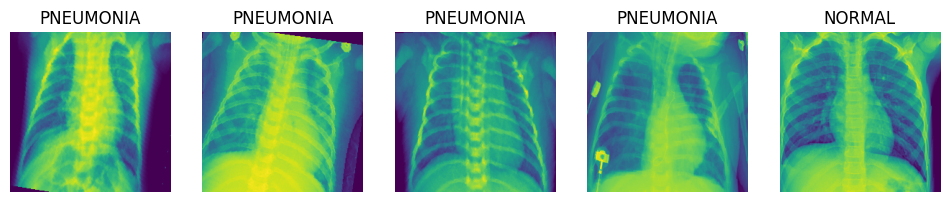

Epoch 1: Melhor modelo (simples) salvo! (Val Loss: 0.3918)
Epoch 2: Melhor modelo (simples) salvo! (Val Loss: 0.2898)
Epoch 3: Melhor modelo (simples) salvo! (Val Loss: 0.2239)
Epoch 4: Melhor modelo (simples) salvo! (Val Loss: 0.2095)
Epoch 5/30 | Simple Train Loss: 0.1824 | Simple Val Loss: 0.2101
Epoch 6: Melhor modelo (simples) salvo! (Val Loss: 0.2035)
Epoch 7: Melhor modelo (simples) salvo! (Val Loss: 0.2031)
Epoch 8: Melhor modelo (simples) salvo! (Val Loss: 0.1860)
Epoch 10/30 | Simple Train Loss: 0.1644 | Simple Val Loss: 0.2180
Epoch 15/30 | Simple Train Loss: 0.1669 | Simple Val Loss: 0.1995
Epoch 18: Melhor modelo (simples) salvo! (Val Loss: 0.1762)
Epoch 19: Melhor modelo (simples) salvo! (Val Loss: 0.1720)
Epoch 20/30 | Simple Train Loss: 0.1469 | Simple Val Loss: 0.1825
Epoch 25/30 | Simple Train Loss: 0.1416 | Simple Val Loss: 0.1984
Epoch 30/30 | Simple Train Loss: 0.1414 | Simple Val Loss: 0.1724


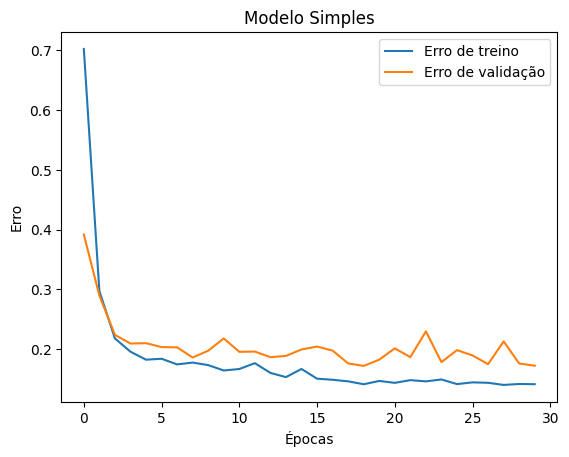

--- Relatório Final (Modelo Simples) ---
Acurácia (Accuracy):   94.54%
Precisão (Precision):  96.92%
Sensibilidade (Recall):95.56%
F1 Score:              96.24%


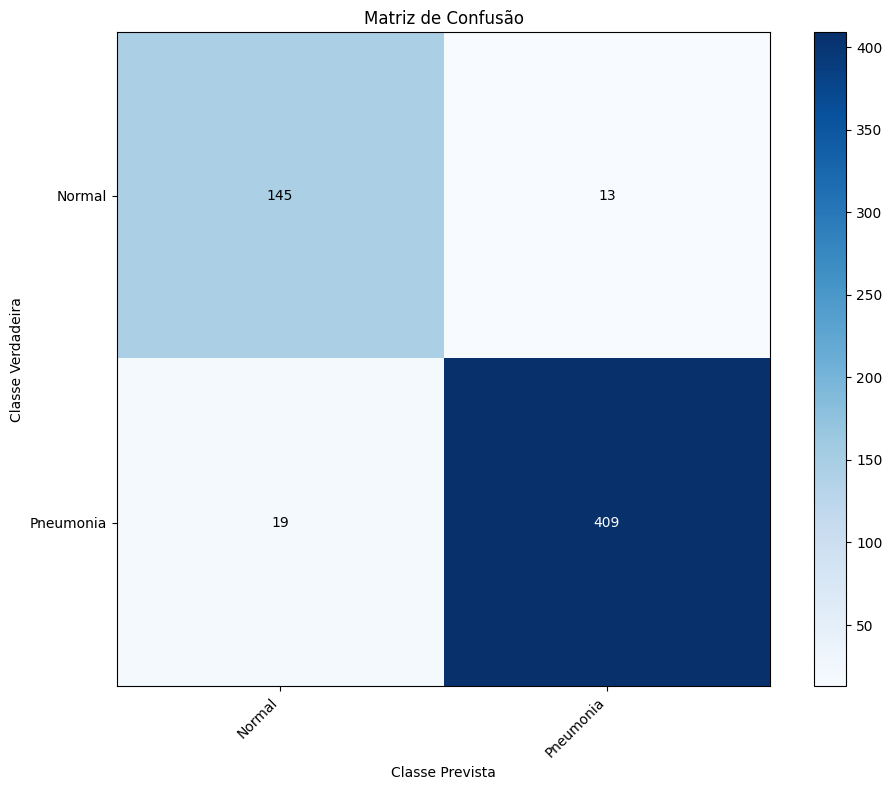

In [27]:
ASSETS_PATH = os.path.join(project_root, "assets/")
DB_PATH = os.path.join(project_root, "db/")
MODELS_PATH = os.path.join(project_root, "models/")
EPOCHS = 30
DEVICE = "cuda"

os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(ASSETS_PATH, exist_ok=True)
train_loader, val_loader, test_loader = getDataLoaders(DB_PATH, batch_size=128)
print("------------------------------------ Exemplo de lote ------------------------------------")
sampleBatch(train_loader)

simpleModel = cnnModel(
    device=DEVICE,
    filters_list=[32, 64]
)

optimizer_simple = optim.Adam(simpleModel.model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()
num_epochs = EPOCHS

best_simple_val_loss = float('inf')
for epoch in range(num_epochs):
    simpleModel.trainModel(train_loader, loss_fn, optimizer_simple)
    simpleModel.validateModel(val_loader, loss_fn)

    if simpleModel.val_loss[-1] < best_simple_val_loss:
        best_simple_val_loss = simpleModel.val_loss[-1]
        simpleModel.saveCheckpoint(os.path.join(MODELS_PATH, "best_simple_cnn_model.pth"))
        print(f"Epoch {epoch+1}: Melhor modelo (simples) salvo! (Val Loss: {best_simple_val_loss:.4f})")

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Simple Train Loss: {simpleModel.train_loss[epoch]:.4f} | Simple Val Loss: {simpleModel.val_loss[epoch]:.4f}")


plotLosses(
    "Modelo Simples",
    simpleModel.train_loss,
    simpleModel.val_loss,
    "Erro de treino",
    "Erro de validação",
    EPOCHS,
    os.path.join(ASSETS_PATH, "Simple_CNN_Losses.png")
)

simpleModel.model.load_state_dict(torch.load(os.path.join(MODELS_PATH, "best_simple_cnn_model.pth")))
simpleModel.testModel(test_loader)
print(f"--- Relatório Final (Modelo Simples) ---")
print(f"Acurácia (Accuracy):   {simpleModel.acc*100:.2f}%")
print(f"Precisão (Precision):  {simpleModel.prec*100:.2f}%")
print(f"Sensibilidade (Recall):{simpleModel.rec*100:.2f}%")
print(f"F1 Score:              {simpleModel.f1*100:.2f}%")

plotCMatrix(
    simpleModel.test_class,
    simpleModel.predicted_class,
    ['Normal', 'Pneumonia'],
    os.path.join(ASSETS_PATH, "Simple_CNN_ConfusionMatrix.png")
)

## Modelo CNN mais complexo, com camadas de 32, 64 e 128 filtros, respectivamente, dropout, Batch Normalization e Global Average Pooling

In [ ]:
ASSETS_PATH = os.path.join(project_root, "assets/")
DB_PATH = os.path.join(project_root, "db/")
MODELS_PATH = os.path.join(project_root, "models/")
EPOCHS = 30
DEVICE = "cuda"

os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(ASSETS_PATH, exist_ok=True)
train_loader, val_loader, test_loader = getDataLoaders(DB_PATH, batch_size=128)
print("------------------------------------ Exemplo de lote ------------------------------------")
sampleBatch(train_loader)

completeModel = cnnModel(
    device=DEVICE,
    filters_list=[32, 64, 128],
    dropout=True,
    batch_norm=True,
    GAP=True
)

optimizer_complete = optim.Adam(completeModel.model.parameters(), lr=0.0001)
loss_fn = nn.CrossEntropyLoss()
num_epochs = EPOCHS

best_complete_val_loss = float('inf')
for epoch in range(num_epochs):
    completeModel.trainModel(train_loader, loss_fn, optimizer_complete)
    completeModel.validateModel(val_loader, loss_fn)

    if completeModel.val_loss[-1] < best_complete_val_loss:
        best_complete_val_loss = completeModel.val_loss[-1]
        completeModel.saveCheckpoint(os.path.join(MODELS_PATH, "best_complete_cnn_model.pth"))
        print(f"Epoch {epoch+1}: Melhor modelo (completo) salvo! (Val Loss: {best_complete_val_loss:.4f})")

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Complete Train Loss: {completeModel.train_loss[epoch]:.4f} | Complete Val Loss: {completeModel.val_loss[epoch]:.4f}")

plotLosses(
    "Modelo Completo",
    completeModel.train_loss,
    completeModel.val_loss,
    "Erro de treino",
    "Erro de validação",
    EPOCHS,
    os.path.join(ASSETS_PATH, "Simple_CNN_Losses.png")
)

completeModel.model.load_state_dict(torch.load(os.path.join(MODELS_PATH, "best_complete_cnn_model.pth")))
completeModel.testModel(test_loader)
print(f"--- Relatório Final (Modelo Completo) ---")
print(f"Acurácia (Accuracy):   {completeModel.acc*100:.2f}%")
print(f"Precisão (Precision):  {completeModel.prec*100:.2f}%")
print(f"Sensibilidade (Recall):{completeModel.rec*100:.2f}%")
print(f"F1 Score:              {completeModel.f1*100:.2f}%")

plotCMatrix(
    completeModel.test_class,
    completeModel.predicted_class,
    ['Normal', 'Pneumonia'],
    os.path.join(ASSETS_PATH, "Complete_CNN_ConfusionMatrix.png")
)